In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys, time, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    RepeatedStratifiedKFold, StratifiedKFold, GridSearchCV,
    cross_val_score, cross_val_predict, train_test_split
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn import metrics
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    balanced_accuracy_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
from scipy.stats import ttest_rel, wilcoxon

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("seaborn     :", sns.__version__)

try:
    import imblearn
    print("imbalanced-learn:", imblearn.__version__)
except ImportError:
    print("imbalanced-learn: NOT INSTALLED (pip install imbalanced-learn)")

try:
    import shap
    print("shap        :", shap.__version__)
except ImportError:
    print("shap        : NOT INSTALLED (pip install shap)")

Python      : 3.12.13
Platform    : Linux-6.6.122+-x86_64-with-glibc2.35
numpy       : 2.0.2
pandas      : 2.2.2
scikit-learn: 1.6.1
seaborn     : 0.13.2
imbalanced-learn: NOT INSTALLED (pip install imbalanced-learn)
shap        : NOT INSTALLED (pip install shap)


In [ ]:
#Uploading file to Colab
from google.colab import files
uploaded = files.upload()
#Reading Dataset
import pandas as pd
import io
data = pd.read_csv(io.BytesIO(uploaded['Toddler Autism dataset July 2018.csv']))


print("Shape:", data.shape)
data.head()

Saving Toddler Autism dataset July 2018.csv to Toddler Autism dataset July 2018.csv
Shape: (1054, 17)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Class
0,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,No
1,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,Yes
2,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,Yes
3,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,Yes
4,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,Yes


Class
Yes    728
No     326
Name: count, dtype: int64

Class balance: 69.07% positive (ASD traits)


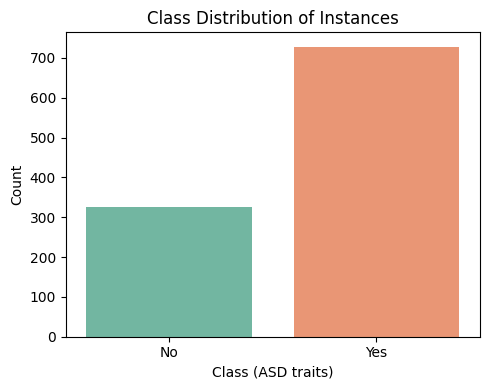

In [ ]:
print(data['Class'].value_counts())
print("\nClass balance: {:.2f}% positive (ASD traits)".format(
    100 * data['Class'].value_counts(normalize=True).get('Yes', np.nan)))

plt.figure(figsize=(5, 4))
sns.countplot(x='Class', data=data, palette='Set2')
plt.title('Class Distribution of Instances')
plt.xlabel('Class (ASD traits)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=150)
plt.show()

In [ ]:
check = data.copy()
check['Class_bin'] = (check['Class'] == 'Yes').astype(int)
check['rule_pred'] = (check['Qchat-10-Score'] > 3).astype(int)
agreement = (check['Class_bin'] == check['rule_pred']).mean()
print(f"Agreement between Class and rule 'Qchat-10-Score > 3': {agreement*100:.2f}%")
print("\nCross-tab (rows = actual Class, cols = rule prediction):")
print(pd.crosstab(check['Class'], check['rule_pred']))

Agreement between Class and rule 'Qchat-10-Score > 3': 100.00%

Cross-tab (rows = actual Class, cols = rule prediction):
rule_pred    0    1
Class              
No         326    0
Yes          0  728


In [ ]:
le = LabelEncoder()
for col in ["Sex", "Ethnicity", "Jaundice", "Family_mem_with_ASD", "Class"]:
    data[col] = le.fit_transform(data[col])
# Class: 0 = No ASD traits, 1 = ASD traits
print(data[['Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Class']].head())

   Sex  Ethnicity  Jaundice  Family_mem_with_ASD  Class
0    0          8         1                    0      0
1    1          5         1                    0      1
2    1          8         1                    0      1
3    1          0         0                    0      1
4    0          5         0                    1      1


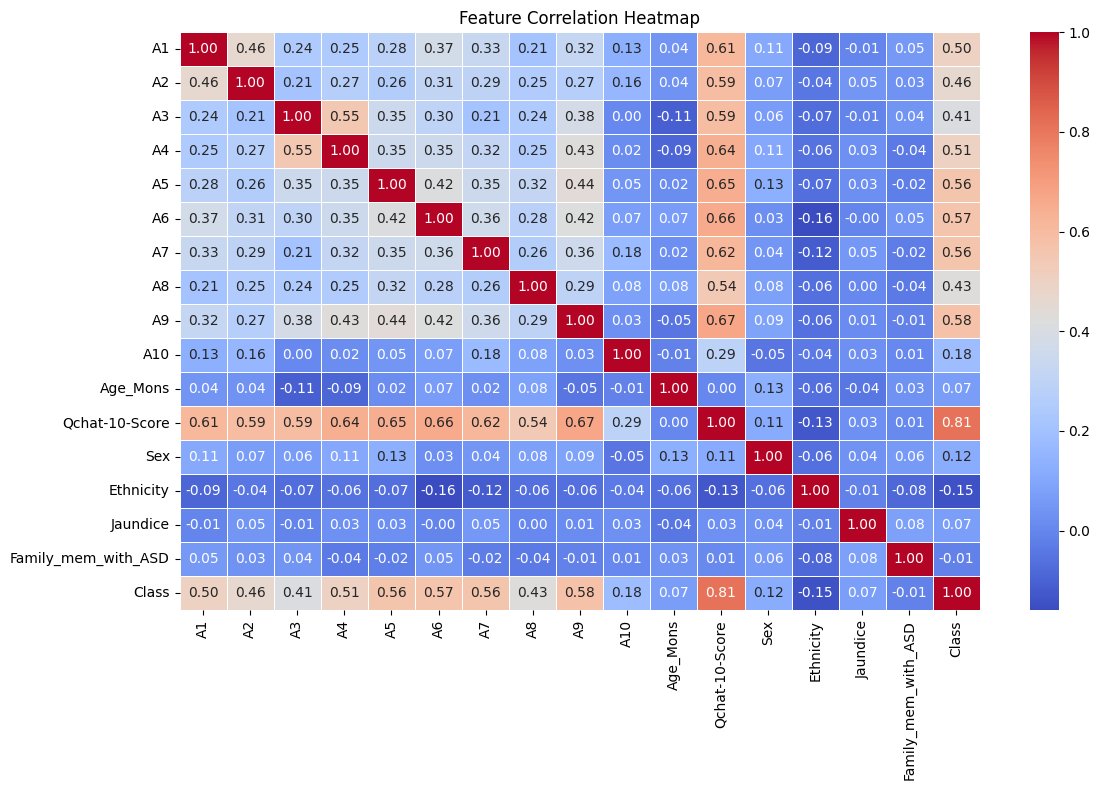

In [ ]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150)
plt.show()

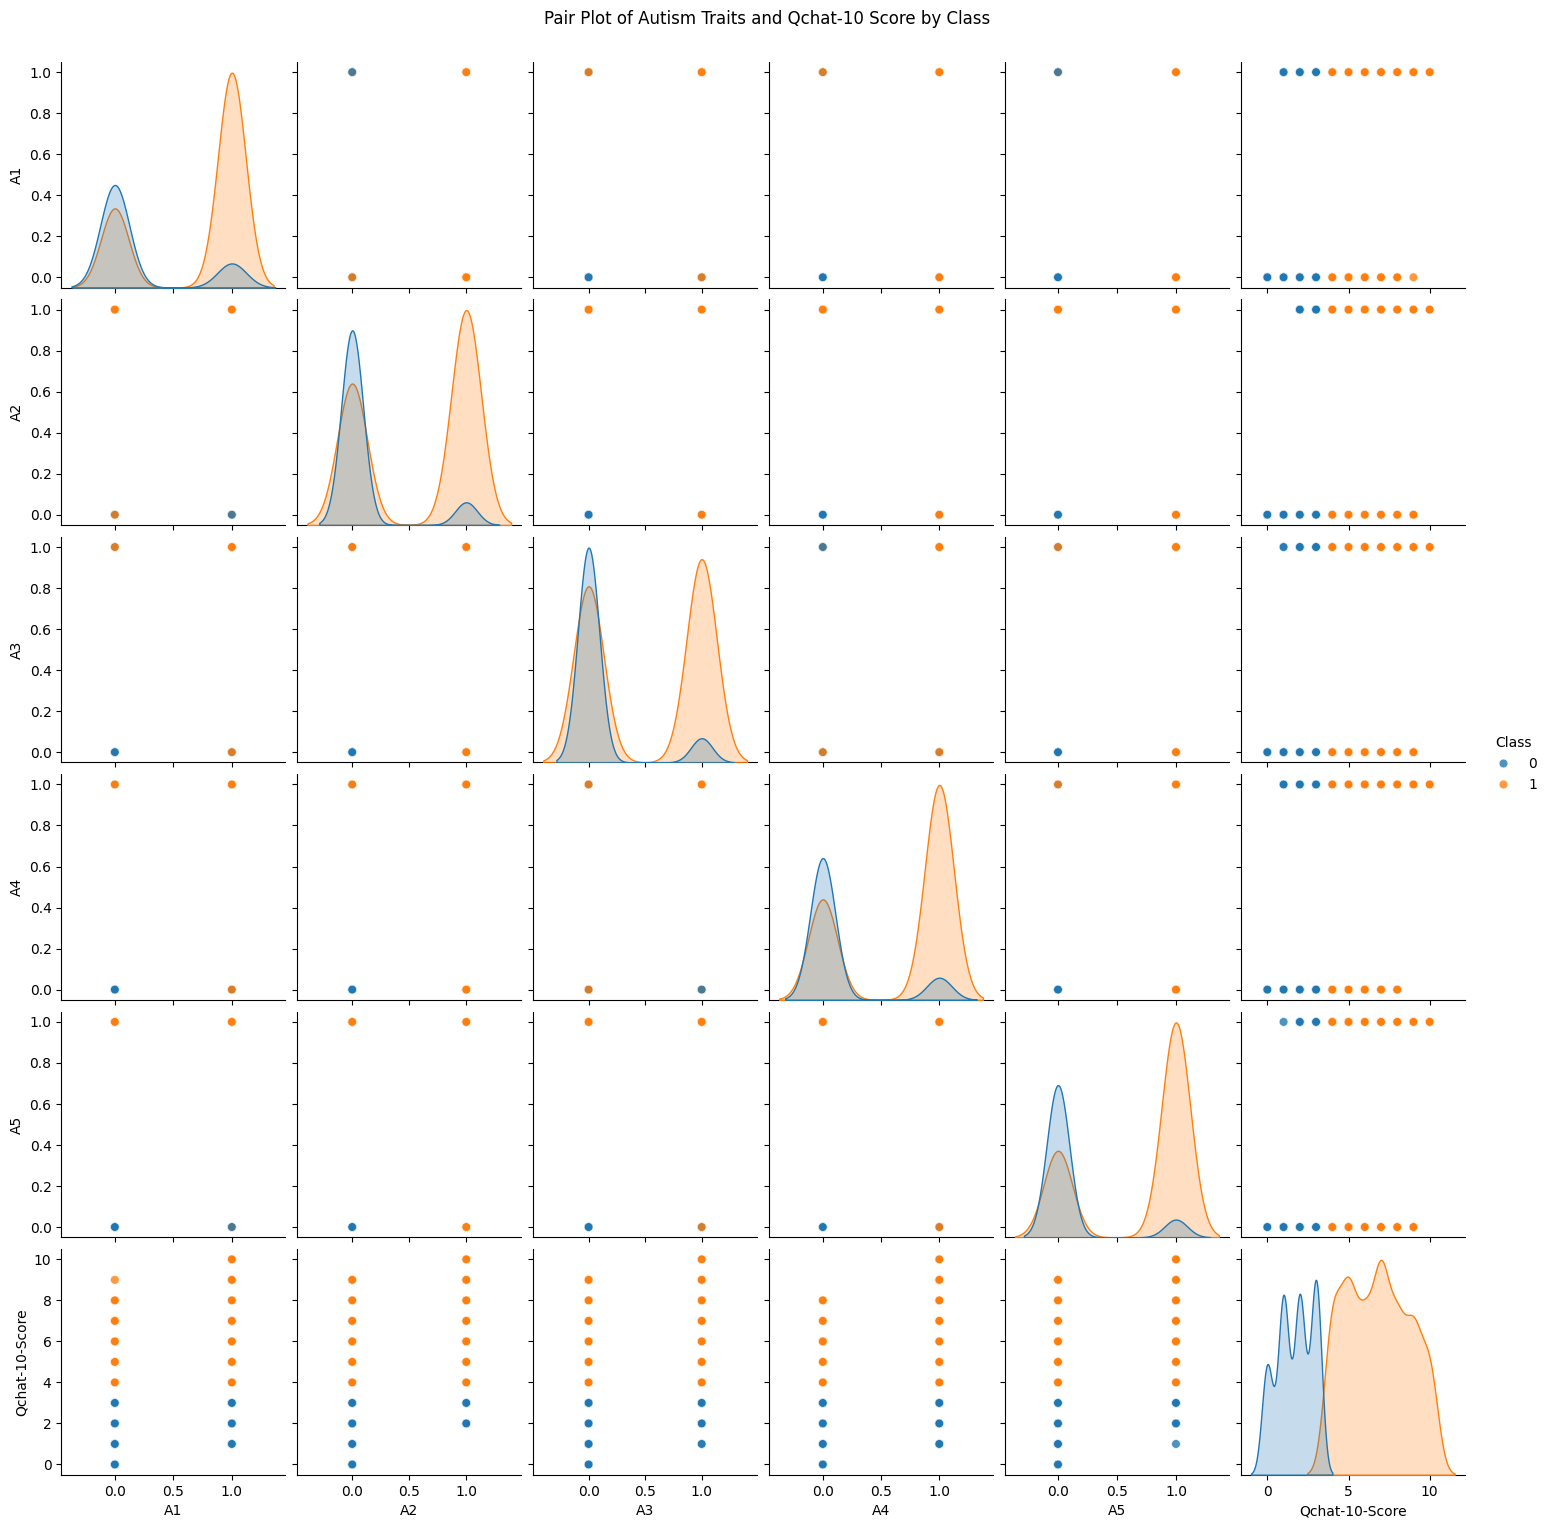

In [ ]:
selected_features = ['A1', 'A2', 'A3', 'A4', 'A5', 'Qchat-10-Score', 'Class']
sns.pairplot(data[selected_features], hue='Class', diag_kind='kde',
             plot_kws={'alpha': 0.8, 's': 40})
plt.suptitle('Pair Plot of Autism Traits and Qchat-10 Score by Class', y=1.02)
plt.savefig('fig_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
TARGET = "Class"
leakage_features = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
                     'Qchat-10-Score']

X_with_qchat = data.drop(columns=[TARGET])
X_no_qchat = data.drop(columns=leakage_features + [TARGET])
y = data[TARGET]

experiments = {
    "WITH_QCHAT": X_with_qchat,
    "NO_QCHAT": X_no_qchat,
}

for name, X in experiments.items():
    print(f"{name}: {X.shape[1]} features -> {X.columns.tolist()}")

WITH_QCHAT: 16 features -> ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD']
NO_QCHAT: 5 features -> ['Age_Mons', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD']


In [ ]:
def make_models():
    return {
        "SVM": (
            Pipeline([("scaler", StandardScaler()),
                      ("clf", SVC(probability=True, random_state=RANDOM_STATE))]),
            {"clf__C": [1, 10], "clf__gamma": ["scale", "auto"]},
        ),
        "KNN": (
            Pipeline([("scaler", StandardScaler()),
                      ("clf", KNeighborsClassifier())]),
            {"clf__n_neighbors": [5, 7, 9], "clf__weights": ["uniform", "distance"]},
        ),
        "Decision Tree": (
            DecisionTreeClassifier(random_state=RANDOM_STATE),
            {"max_depth": [3, 5, 7, None], "min_samples_leaf": [1, 3, 5]},
        ),
        "Naive Bayes": (
            GaussianNB(),
            {"var_smoothing": np.logspace(-9, -6, 4)},
        ),
        "Random Forest": (
            RandomForestClassifier(random_state=RANDOM_STATE),
            {"n_estimators": [100], "max_depth": [10, None]},
        ),
        "AdaBoost": (
            AdaBoostClassifier(random_state=RANDOM_STATE),
            {"n_estimators": [50, 100], "learning_rate": [1.0]},
        ),
        "Logistic Regression": (
            Pipeline([("scaler", StandardScaler()),
                      ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
            {"clf__C": [0.1, 1, 10]},
        ),
    }


def nested_cv_metrics(estimator, param_grid, X, y, repeated_cv, predict_cv, inner_cv=5):
    """Nested CV: inner GridSearchCV tunes hyperparameters.
    - `repeated_cv` (RepeatedStratifiedKFold) gives per-fold accuracy for
      variance reporting and significance testing.
    - `predict_cv` (a single StratifiedKFold — cross_val_predict requires
      a non-overlapping partition, which a *repeated* CV does not provide)
      gives one aggregated prediction/probability per sample for
      confusion matrices, ROC/PR curves, etc.
    """
    gs = GridSearchCV(estimator, param_grid, cv=inner_cv, n_jobs=-1)
    fold_acc = cross_val_score(gs, X, y, cv=repeated_cv, n_jobs=1)
    y_pred = cross_val_predict(gs, X, y, cv=predict_cv, n_jobs=1)
    try:
        y_proba = cross_val_predict(gs, X, y, cv=predict_cv, n_jobs=1,
                                     method='predict_proba')[:, 1]
    except Exception:
        y_proba = None
    return fold_acc, y_pred, y_proba


def summarize(y_true, y_pred, y_proba, fold_acc):
    cm = metrics.confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    sensitivity = TP / (TP + FN) if (TP + FN) else np.nan
    specificity = TN / (TN + FP) if (TN + FP) else np.nan
    precision = TP / (TP + FP) if (TP + FP) else np.nan
    f1 = (2 * precision * sensitivity / (precision + sensitivity)
          if (precision and sensitivity) else np.nan)
    mcc = metrics.matthews_corrcoef(y_true, y_pred)
    kappa = metrics.cohen_kappa_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    logloss = metrics.log_loss(y_true, y_proba) if y_proba is not None else np.nan
    return {
        "Accuracy (mean)": fold_acc.mean() * 100,
        "Accuracy (std)": fold_acc.std() * 100,
        "Sensitivity (%)": sensitivity * 100,
        "Specificity (%)": specificity * 100,
        "Precision (%)": precision * 100,
        "F1 (%)": f1 * 100,
        "MCC (%)": mcc * 100,
        "Cohen's Kappa (%)": kappa * 100,
        "ROC-AUC": roc_auc,
        "Log-Loss": logloss,
        "TN": TN, "FP": FP, "FN": FN, "TP": TP,
    }

In [ ]:
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

predict_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Rule-based baseline (WITH_QCHAT)
rule_pred = (data['Qchat-10-Score'] > 3).astype(int)
rule_metrics = summarize(y, rule_pred, rule_pred.astype(float), np.array([metrics.accuracy_score(y, rule_pred)]))
print("Rule-based baseline (Qchat-10-Score > 3), WITH_QCHAT-equivalent:")
for k, v in rule_metrics.items():
    print(f"  {k}: {v}")

Rule-based baseline (Qchat-10-Score > 3), WITH_QCHAT-equivalent:
  Accuracy (mean): 100.0
  Accuracy (std): 0.0
  Sensitivity (%): 100.0
  Specificity (%): 100.0
  Precision (%): 100.0
  F1 (%): 100.0
  MCC (%): 100.0
  Cohen's Kappa (%): 100.0
  ROC-AUC: 1.0
  Log-Loss: 2.2204460492503136e-16
  TN: 326
  FP: 0
  FN: 0
  TP: 728


In [ ]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_fold_acc = cross_val_score(dummy, X_no_qchat, y, cv=outer_cv)
dummy_pred = cross_val_predict(dummy, X_no_qchat, y, cv=predict_cv)
print(f"Majority-class baseline accuracy (NO_QCHAT features irrelevant): "
      f"{dummy_fold_acc.mean()*100:.2f}% +/- {dummy_fold_acc.std()*100:.2f}%")

Majority-class baseline accuracy (NO_QCHAT features irrelevant): 69.07% +/- 0.18%


In [ ]:
results = {}
fold_accs = {}
predictions = {}

for exp_name, X in experiments.items():
    print(f"\n===== Experiment: {exp_name} ({X.shape[1]} features) =====")
    results[exp_name] = {}
    fold_accs[exp_name] = {}
    predictions[exp_name] = {}
    for model_name, (est, grid) in make_models().items():
        t0 = time.time()
        facc, y_pred, y_proba = nested_cv_metrics(est, grid, X, y, outer_cv, predict_cv)
        m = summarize(y, y_pred, y_proba, facc)
        results[exp_name][model_name] = m
        fold_accs[exp_name][model_name] = facc
        predictions[exp_name][model_name] = (y_pred, y_proba)
        print(f"  {model_name:22s} acc = {facc.mean()*100:6.2f}% +/- {facc.std()*100:4.2f}"
              f"   ({time.time()-t0:5.1f}s)")


===== Experiment: WITH_QCHAT (16 features) =====
  SVM                    acc =  99.81% +/- 0.31   (  6.3s)
  KNN                    acc =  96.39% +/- 1.36   (  2.8s)
  Decision Tree          acc = 100.00% +/- 0.00   (  3.3s)
  Naive Bayes            acc =  97.58% +/- 1.49   (  1.3s)
  Random Forest          acc = 100.00% +/- 0.00   ( 13.5s)
  AdaBoost               acc = 100.00% +/- 0.00   (  0.9s)
  Logistic Regression    acc = 100.00% +/- 0.00   (  4.1s)

===== Experiment: NO_QCHAT (5 features) =====
  SVM                    acc =  70.92% +/- 1.75   ( 15.1s)
  KNN                    acc =  70.07% +/- 2.10   (  2.2s)
  Decision Tree          acc =  68.60% +/- 1.54   (  2.2s)
  Naive Bayes            acc =  69.92% +/- 1.70   (  0.9s)
  Random Forest          acc =  69.64% +/- 1.99   ( 15.5s)
  AdaBoost               acc =  69.40% +/- 1.55   ( 13.5s)
  Logistic Regression    acc =  69.26% +/- 0.82   (  1.5s)


In [ ]:
tables = {}
for exp_name in experiments:
    df = pd.DataFrame(results[exp_name]).T
    df["Accuracy (%)"] = df["Accuracy (mean)"].round(2).astype(str) + " +/- " + df["Accuracy (std)"].round(2).astype(str)
    cols = ["Accuracy (%)", "Sensitivity (%)", "Specificity (%)", "Precision (%)",
            "F1 (%)", "MCC (%)", "Cohen's Kappa (%)", "ROC-AUC", "Log-Loss"]
    tables[exp_name] = df[cols].round(3)
    print(f"\n--- {exp_name} ---")
    print(tables[exp_name])
    tables[exp_name].to_csv(f"results_{exp_name}.csv")


--- WITH_QCHAT ---
                       Accuracy (%)  Sensitivity (%)  Specificity (%)  \
SVM                  99.81 +/- 0.31          100.000           99.693   
KNN                  96.39 +/- 1.36           96.016           97.853   
Decision Tree         100.0 +/- 0.0          100.000          100.000   
Naive Bayes          97.58 +/- 1.49           98.352           96.012   
Random Forest         100.0 +/- 0.0          100.000          100.000   
AdaBoost              100.0 +/- 0.0          100.000          100.000   
Logistic Regression   100.0 +/- 0.0          100.000          100.000   

                     Precision (%)   F1 (%)  MCC (%)  Cohen's Kappa (%)  \
SVM                         99.863   99.931   99.778             99.778   
KNN                         99.008   97.490   92.258             92.152   
Decision Tree              100.000  100.000  100.000            100.000   
Naive Bayes                 98.217   98.284   94.444             94.444   
Random Forest       

In [ ]:
sig_rows = []
for exp_name in experiments:
    accs = fold_accs[exp_name]
    best_model = max(accs, key=lambda m: accs[m].mean())
    for model_name, arr in accs.items():
        if model_name == best_model:
            continue
        t_stat, t_p = ttest_rel(accs[best_model], arr)
        try:
            w_stat, w_p = wilcoxon(accs[best_model], arr)
        except ValueError:
            w_stat, w_p = np.nan, np.nan
        sig_rows.append({
            "Experiment": exp_name,
            "Best model": best_model,
            "Compared to": model_name,
            "Mean acc diff (pp)": (accs[best_model].mean() - arr.mean()) * 100,
            "Paired t-test p": t_p,
            "Wilcoxon p": w_p,
            "Significant (p<0.05)": (t_p < 0.05),
        })
sig_df = pd.DataFrame(sig_rows)
sig_df.to_csv("statistical_significance.csv", index=False)
sig_df

,Experiment,Best model,Compared to,Mean acc diff (pp),Paired t-test p,Wilcoxon p,Significant (p<0.05)
0,WITH_QCHAT,Decision Tree,SVM,0.190025,0.103568,0.250000,False
1,WITH_QCHAT,Decision Tree,KNN,3.605281,0.000023,0.001953,True
2,WITH_QCHAT,Decision Tree,Naive Bayes,2.419770,0.000887,0.001953,True
3,WITH_QCHAT,Decision Tree,Random Forest,0.000000,NaN,1.000000,False
4,WITH_QCHAT,Decision Tree,AdaBoost,0.000000,NaN,1.000000,False
5,WITH_QCHAT,Decision Tree,Logistic Regression,0.000000,NaN,1.000000,False
6,NO_QCHAT,SVM,KNN,0.852855,0.244241,0.390625,False
7,NO_QCHAT,SVM,Decision Tree,2.324532,0.003668,0.001953,True
8,NO_QCHAT,SVM,Naive Bayes,0.995486,0.181066,0.238281,False
9,NO_QCHAT,SVM,Random Forest,1.278718,0.102479,0.128906,False


In [ ]:
pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 8.5 MB/s eta 0:00:00


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

imbalance_rows = []
X_nq = X_no_qchat

balanced_variants = {
    "SVM (class_weight=balanced)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Decision Tree (class_weight=balanced)": DecisionTreeClassifier(
        class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest (class_weight=balanced)": RandomForestClassifier(
        class_weight="balanced", random_state=RANDOM_STATE),
    "Logistic Regression (class_weight=balanced)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                    random_state=RANDOM_STATE))]),
    "KNN (SMOTE)": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())]),
    "Naive Bayes (SMOTE)": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", GaussianNB())]),
}

baseline_bal_acc = {
    "SVM": balanced_accuracy_score(y, predictions["NO_QCHAT"]["SVM"][0]),
    "Decision Tree": balanced_accuracy_score(y, predictions["NO_QCHAT"]["Decision Tree"][0]),
    "Random Forest": balanced_accuracy_score(y, predictions["NO_QCHAT"]["Random Forest"][0]),
    "Logistic Regression": balanced_accuracy_score(y, predictions["NO_QCHAT"]["Logistic Regression"][0]),
    "KNN": balanced_accuracy_score(y, predictions["NO_QCHAT"]["KNN"][0]),
    "Naive Bayes": balanced_accuracy_score(y, predictions["NO_QCHAT"]["Naive Bayes"][0]),
}

for name, est in balanced_variants.items():
    base_name = name.split(" (")[0]
    pred = cross_val_predict(est, X_nq, y, cv=predict_cv)
    bal_acc = balanced_accuracy_score(y, pred)
    imbalance_rows.append({
        "Model": base_name,
        "Balanced accuracy - baseline (%)": baseline_bal_acc[base_name] * 100,
        "Balanced accuracy - rebalanced (%)": bal_acc * 100,
        "Change (pp)": (bal_acc - baseline_bal_acc[base_name]) * 100,
    })

imbalance_df = pd.DataFrame(imbalance_rows)
imbalance_df.to_csv("class_imbalance_comparison.csv", index=False)
imbalance_df.round(2)

,Model,Balanced accuracy - baseline (%),Balanced accuracy - rebalanced (%),Change (pp)
0,SVM,55.18,61.74,6.56
1,Decision Tree,56.09,60.43,4.34
2,Random Forest,60.45,59.89,-0.56
3,Logistic Regression,52.99,58.96,5.97
4,KNN,59.28,62.36,3.08
5,Naive Bayes,54.46,53.08,-1.38


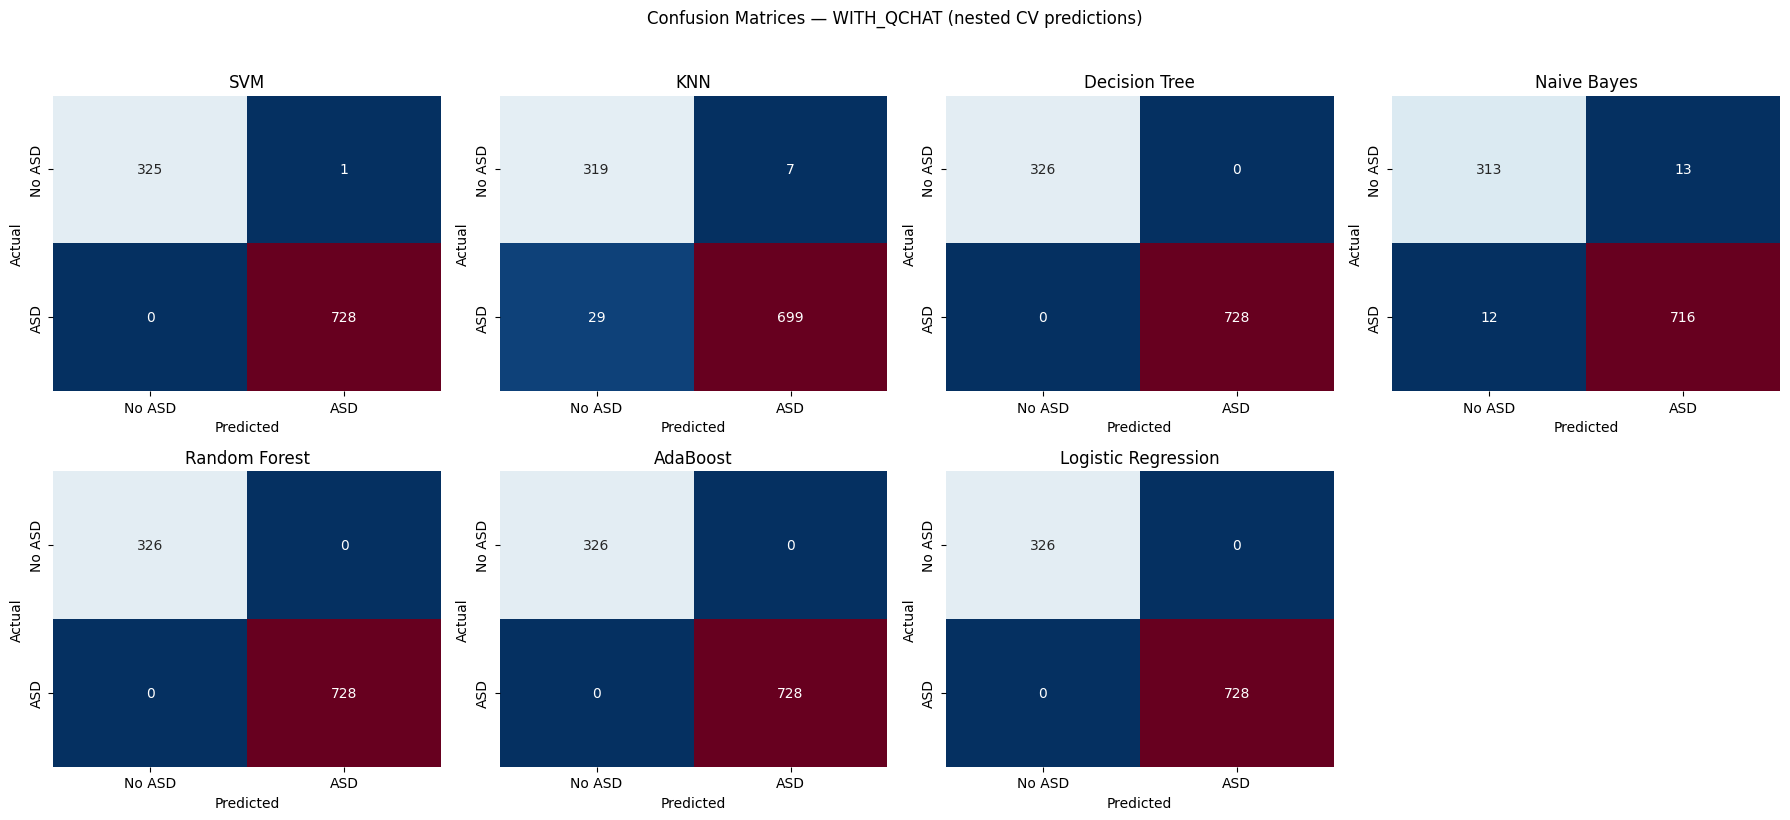

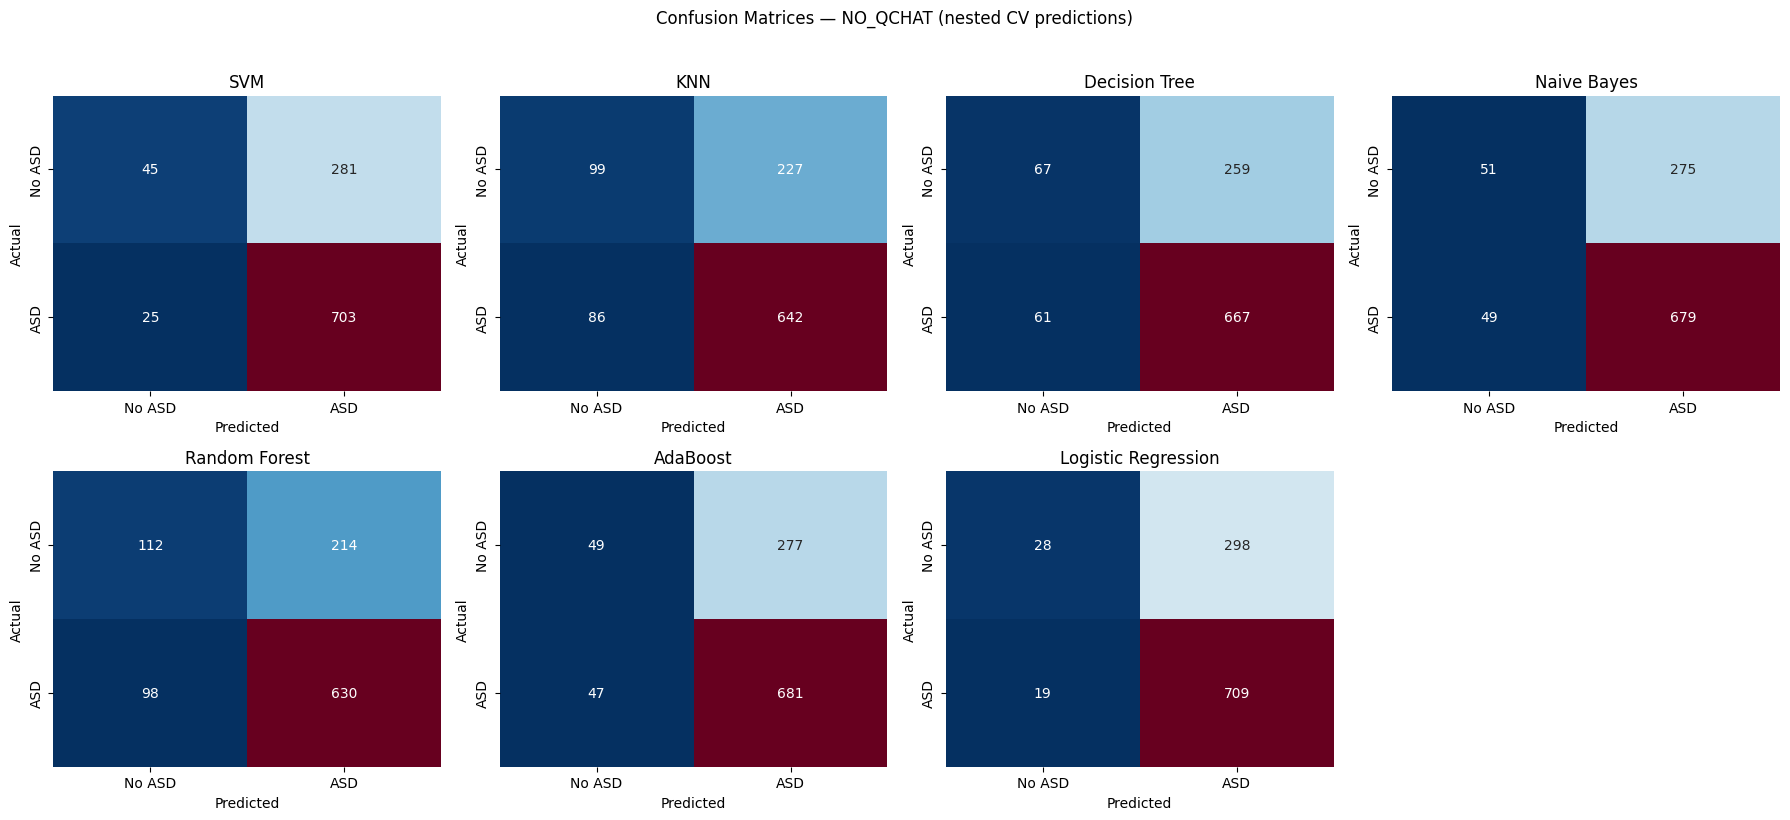

In [ ]:
for exp_name in experiments:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.ravel()
    for i, model_name in enumerate(make_models().keys()):
        y_pred, _ = predictions[exp_name][model_name]
        cm = metrics.confusion_matrix(y, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu_r', cbar=False,
                    xticklabels=['No ASD', 'ASD'], yticklabels=['No ASD', 'ASD'],
                    ax=axes[i])
        axes[i].set_title(model_name)
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    for j in range(len(make_models()), len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle(f'Confusion Matrices — {exp_name} (nested CV predictions)', y=1.02)
    plt.tight_layout()
    plt.savefig(f'fig_confusion_matrices_{exp_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

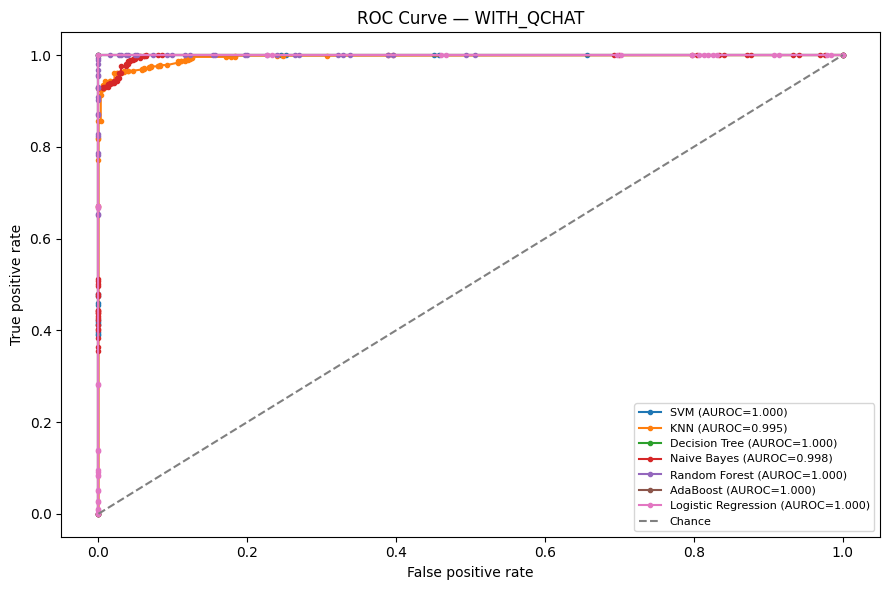

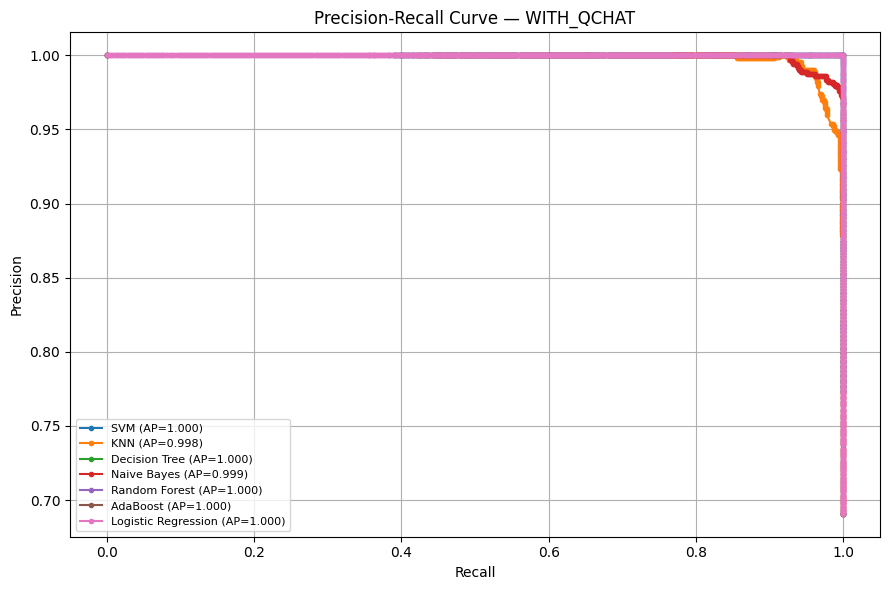

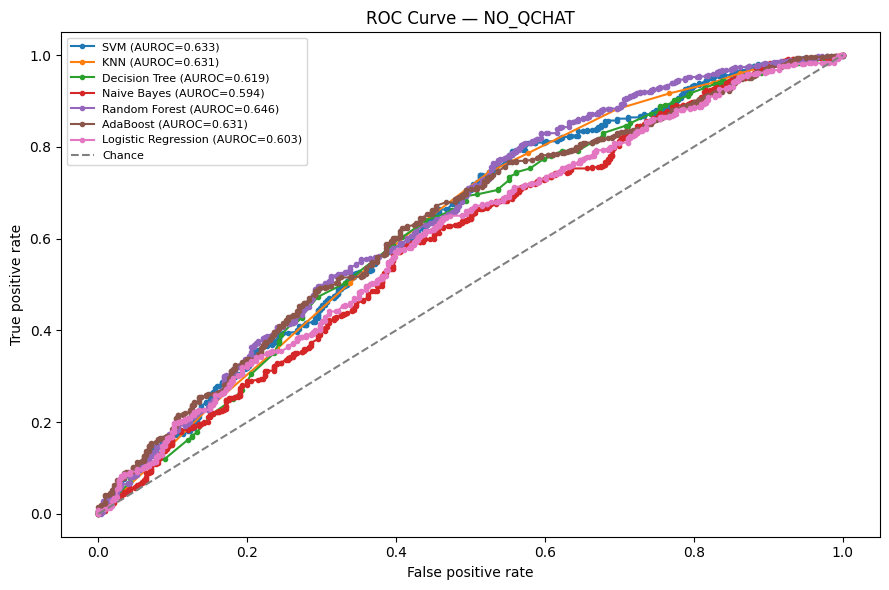

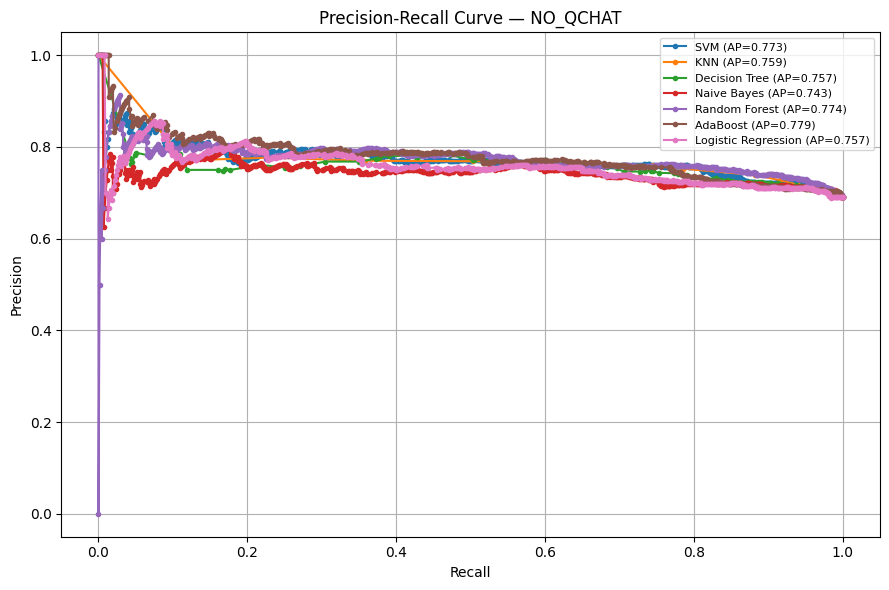

In [ ]:
for exp_name in experiments:
    plt.figure(figsize=(9, 6))
    for model_name in make_models().keys():
        _, y_proba = predictions[exp_name][model_name]
        if y_proba is None:
            continue
        fpr, tpr, _ = roc_curve(y, y_proba)
        auc = roc_auc_score(y, y_proba)
        plt.plot(fpr, tpr, marker='.', label=f'{model_name} (AUROC={auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title(f'ROC Curve — {exp_name}')
    plt.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'fig_roc_{exp_name}.png', dpi=150)
    plt.show()

    plt.figure(figsize=(9, 6))
    for model_name in make_models().keys():
        _, y_proba = predictions[exp_name][model_name]
        if y_proba is None:
            continue
        precision, recall, _ = precision_recall_curve(y, y_proba)
        ap = average_precision_score(y, y_proba)
        plt.plot(recall, precision, marker='.', label=f'{model_name} (AP={ap:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve — {exp_name}')
    plt.legend(loc='best', fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'fig_pr_{exp_name}.png', dpi=150)
    plt.show()

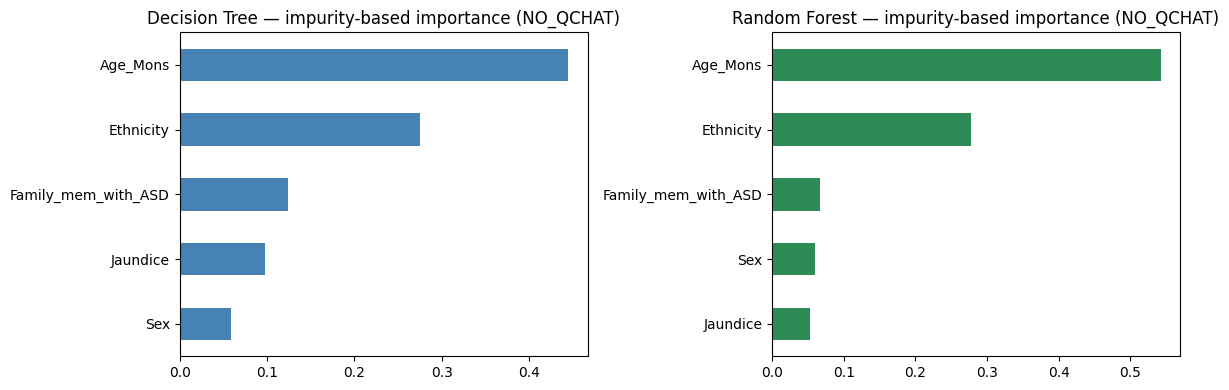

In [ ]:
X_nq_full = X_no_qchat.reset_index(drop=True)
y_full = y.reset_index(drop=True)

dt_full = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5).fit(X_nq_full, y_full)
rf_full = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200).fit(X_nq_full, y_full)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(dt_full.feature_importances_, index=X_nq_full.columns).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Decision Tree — impurity-based importance (NO_QCHAT)')
pd.Series(rf_full.feature_importances_, index=X_nq_full.columns).sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Random Forest — impurity-based importance (NO_QCHAT)')
plt.tight_layout()
plt.savefig('fig_feature_importance_impurity.png', dpi=150)
plt.show()

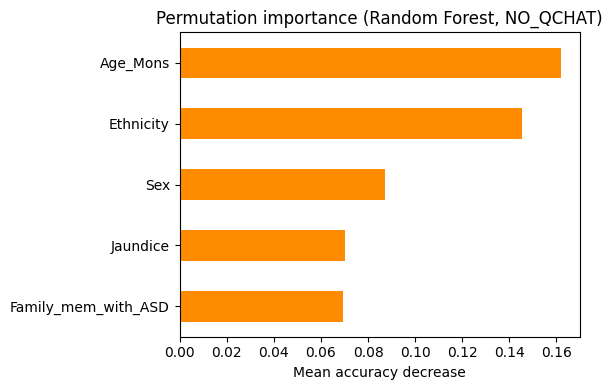

In [ ]:
perm = permutation_importance(rf_full, X_nq_full, y_full, n_repeats=15,
                               random_state=RANDOM_STATE, scoring='accuracy')
perm_series = pd.Series(perm.importances_mean, index=X_nq_full.columns).sort_values()
plt.figure(figsize=(6, 4))
perm_series.plot(kind='barh', color='darkorange')
plt.title('Permutation importance (Random Forest, NO_QCHAT)')
plt.xlabel('Mean accuracy decrease')
plt.tight_layout()
plt.savefig('fig_permutation_importance.png', dpi=150)
plt.show()

In [ ]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 14.8 MB/s eta 0:00:00


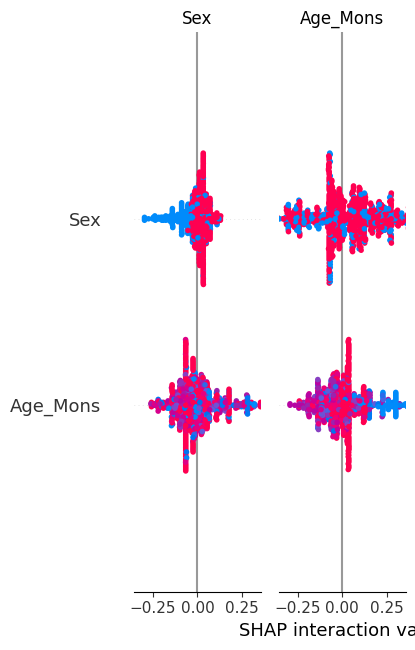

In [ ]:
try:
    import shap
    explainer = shap.TreeExplainer(rf_full)
    shap_values = explainer.shap_values(X_nq_full)
    # shap_values may be a list (per-class) or a single array depending on version
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(sv, X_nq_full, show=False)
    plt.tight_layout()
    plt.savefig('fig_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print("SHAP plot skipped:", e)

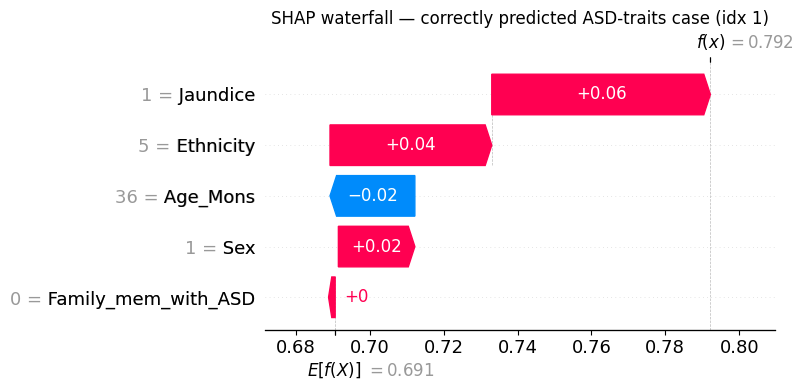

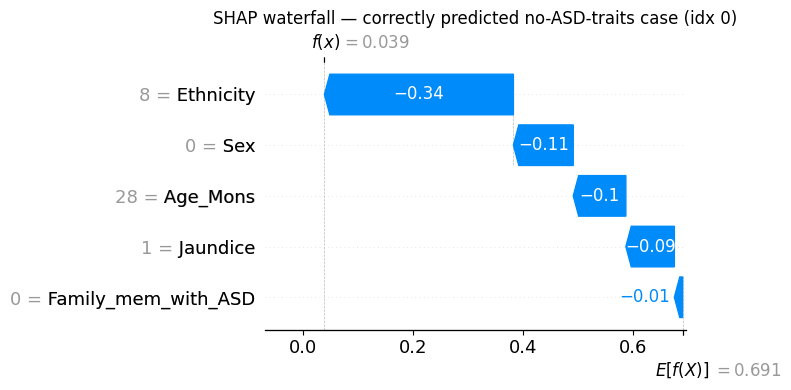

In [ ]:
try:
    import shap
    explainer_wf = shap.TreeExplainer(rf_full)
    exp_values = explainer_wf(X_nq_full)


    if exp_values.values.ndim == 3:
        exp_pos = shap.Explanation(
            values=exp_values.values[:, :, 1],
            base_values=exp_values.base_values[:, 1],
            data=exp_values.data,
            feature_names=exp_values.feature_names,
        )
    else:
        exp_pos = exp_values


    rf_pred_full = rf_full.predict(X_nq_full)
    pos_idx = np.where((y_full.values == 1) & (rf_pred_full == 1))[0]
    neg_idx = np.where((y_full.values == 0) & (rf_pred_full == 0))[0]

    if len(pos_idx) > 0:
        i_pos = pos_idx[0]
        plt.figure()
        shap.plots.waterfall(exp_pos[i_pos], show=False)
        plt.title(f'SHAP waterfall — correctly predicted ASD-traits case (idx {i_pos})')
        plt.tight_layout()
        plt.savefig('fig_shap_waterfall_positive.png', dpi=150, bbox_inches='tight')
        plt.show()

    if len(neg_idx) > 0:
        i_neg = neg_idx[0]
        plt.figure()
        shap.plots.waterfall(exp_pos[i_neg], show=False)
        plt.title(f'SHAP waterfall — correctly predicted no-ASD-traits case (idx {i_neg})')
        plt.tight_layout()
        plt.savefig('fig_shap_waterfall_negative.png', dpi=150, bbox_inches='tight')
        plt.show()
except Exception as e:
    print("SHAP waterfall plot skipped:", e)


In [ ]:
pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=7d75f92e06c95dcd2001aa9a3a4e97846e6392cab53c3bd4d8f22bd4cd239124
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


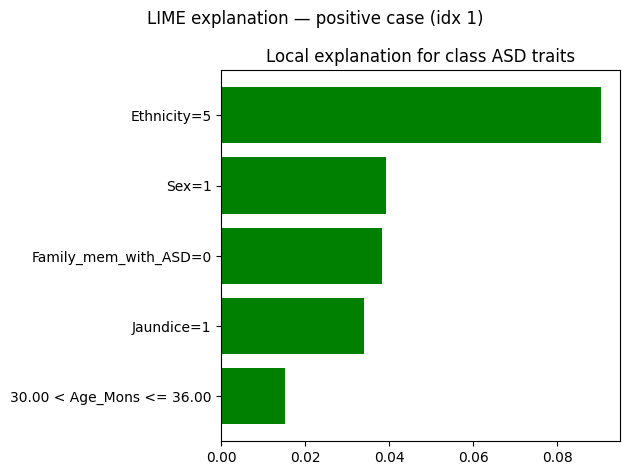


POSITIVE case (idx 1) — LIME feature weights:
  Ethnicity=5                         +0.0904
  Sex=1                               +0.0392
  Family_mem_with_ASD=0               +0.0382
  Jaundice=1                          +0.0339
  30.00 < Age_Mons <= 36.00           +0.0151


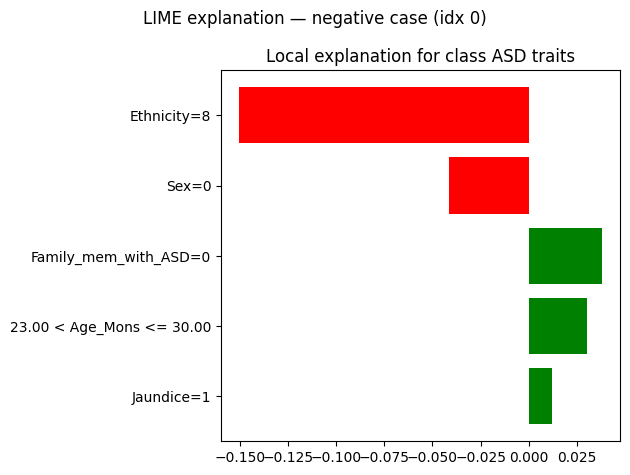


NEGATIVE case (idx 0) — LIME feature weights:
  Ethnicity=8                         -0.1502
  Sex=0                               -0.0416
  Family_mem_with_ASD=0               +0.0378
  23.00 < Age_Mons <= 30.00           +0.0299
  Jaundice=1                          +0.0118


In [ ]:
try:
    from lime.lime_tabular import LimeTabularExplainer


    categorical_features = [X_nq_full.columns.get_loc(c) for c in X_nq_full.columns
                             if c != 'Age_Mons']
    lime_explainer = LimeTabularExplainer(
        training_data=X_nq_full.values,
        feature_names=X_nq_full.columns.tolist(),
        class_names=['No ASD traits', 'ASD traits'],
        categorical_features=categorical_features,
        random_state=RANDOM_STATE,
    )


    for label, idx in [('positive', pos_idx[0] if len(pos_idx) else None),
                        ('negative', neg_idx[0] if len(neg_idx) else None)]:
        if idx is None:
            continue
        lime_exp = lime_explainer.explain_instance(
            X_nq_full.values[idx], rf_full.predict_proba, num_features=5)
        fig = lime_exp.as_pyplot_figure()
        fig.suptitle(f'LIME explanation — {label} case (idx {idx})')
        plt.tight_layout()
        plt.savefig(f'fig_lime_{label}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n{label.upper()} case (idx {idx}) — LIME feature weights:")
        for feat, weight in lime_exp.as_list():
            print(f"  {feat:35s} {weight:+.4f}")
except Exception as e:
    print("LIME explanation skipped:", e)


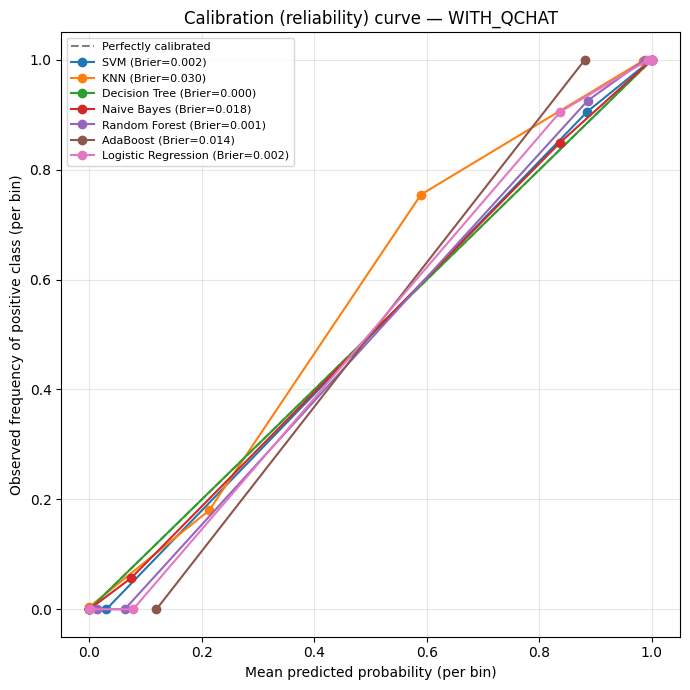

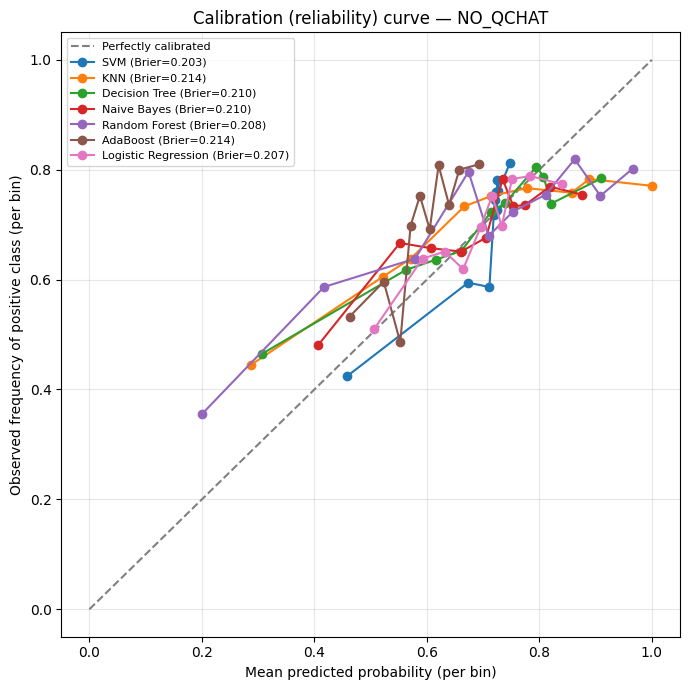


Brier scores (lower = better calibrated):


Experiment,NO_QCHAT,WITH_QCHAT
Model,,
AdaBoost,0.2144,0.0142
Decision Tree,0.2099,0.0000
KNN,0.2138,0.0303
Logistic Regression,0.2074,0.0021
Naive Bayes,0.2097,0.0176
Random Forest,0.2078,0.0012
SVM,0.2030,0.0016


In [ ]:
brier_rows = []
for exp_name in experiments:
    plt.figure(figsize=(7, 7))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
    for model_name in make_models().keys():
        _, y_proba = predictions[exp_name][model_name]
        if y_proba is None:
            continue
        frac_pos, mean_pred = calibration_curve(y, y_proba, n_bins=10, strategy='quantile')
        brier = brier_score_loss(y, y_proba)
        plt.plot(mean_pred, frac_pos, marker='o', label=f'{model_name} (Brier={brier:.3f})')
        brier_rows.append({
            "Experiment": exp_name,
            "Model": model_name,
            "Brier score": brier,
        })
    plt.xlabel('Mean predicted probability (per bin)')
    plt.ylabel('Observed frequency of positive class (per bin)')
    plt.title(f'Calibration (reliability) curve — {exp_name}')
    plt.legend(loc='best', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'fig_calibration_{exp_name}.png', dpi=150)
    plt.show()

brier_df = pd.DataFrame(brier_rows).pivot(index="Model", columns="Experiment", values="Brier score").round(4)
brier_df.to_csv("brier_scores.csv")
print("\nBrier scores (lower = better calibrated):")
brier_df


In [ ]:
def holdout_eval(X, y, test_size, label):
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y)
    rows = {}
    for model_name, (est, grid) in make_models().items():
        gs = GridSearchCV(est, grid, cv=3, n_jobs=-1)
        gs.fit(x_train, y_train)
        best = gs.best_estimator_
        y_pred = best.predict(x_test)
        y_proba = best.predict_proba(x_test)[:, 1] if hasattr(best, "predict_proba") else None
        m = summarize(y_test, y_pred, y_proba, np.array([metrics.accuracy_score(y_test, y_pred)]))
        rows[model_name] = m
    df = pd.DataFrame(rows).T
    cols = ["Accuracy (mean)", "Sensitivity (%)", "Specificity (%)", "Precision (%)",
            "F1 (%)", "MCC (%)", "Cohen's Kappa (%)", "ROC-AUC", "Log-Loss"]
    df = df[cols].rename(columns={"Accuracy (mean)": "Accuracy (%)"}).round(3)
    print(f"\n--- {label} ---")
    print(df)
    df.to_csv(f"holdout_{label}.csv")
    return df

holdout_results = {}
for exp_name, X in experiments.items():
    holdout_results[(exp_name, "80-20")] = holdout_eval(X, y, 0.2, f"{exp_name}_80-20")
    holdout_results[(exp_name, "70-30")] = holdout_eval(X, y, 0.3, f"{exp_name}_70-30")


--- WITH_QCHAT_80-20 ---
                     Accuracy (%)  Sensitivity (%)  Specificity (%)  \
SVM                       100.000          100.000          100.000   
KNN                        96.682           95.890           98.462   
Decision Tree             100.000          100.000          100.000   
Naive Bayes                98.104           99.315           95.385   
Random Forest             100.000          100.000          100.000   
AdaBoost                  100.000          100.000          100.000   
Logistic Regression       100.000          100.000          100.000   

                     Precision (%)   F1 (%)  MCC (%)  Cohen's Kappa (%)  \
SVM                        100.000  100.000  100.000            100.000   
KNN                         99.291   97.561   92.518             92.381   
Decision Tree              100.000  100.000  100.000            100.000   
Naive Bayes                 97.973   98.639   95.539             95.515   
Random Forest              100